# Pima Indians Diabetes Gradient Boosting 분류

## 개요
- Gradient Boosting Classifier로 당뇨병 예측
- 잔차(Error) 기반 순차적 학습
- GridSearchCV로 최적화

## Gradient Boosting 특징
- 잔차를 줄이는 방향(Gradient)으로 학습
- 순차적 트리 추가: 이전 오류 보정
- 높은 예측 성능
- 과적합 제어 가능

## 주요 단계
1. 데이터 로드 및 분리
2. Gradient Boosting 설정
3. GridSearchCV 최적화
4. 성능 평가 및 피처 중요도

## 라이브러리 임포트

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

## 1. 데이터 로드

**Pima Indians Diabetes 데이터셋**
- 768개 샘플, 8개 피처
- 당뇨병 발병 여부 이진 분류

In [5]:
print("Loading Pima Indians Diabetes Dataset...")
pima = fetch_openml(name='diabetes', version=1, as_frame=True)
X = pima.data
# 'tested_negative'를 0으로, 'tested_positive'를 1로 매핑
y = pima.target.map({'tested_negative': 0, 'tested_positive': 1}).astype(int)

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"\n클래스 분포:\n{y.value_counts()}")

Loading Pima Indians Diabetes Dataset...
데이터 크기: (768, 8)
피처 목록: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

클래스 분포:
class
0    500
1    268
Name: count, dtype: int64


**데이터 샘플 확인**

In [6]:
# 데이터 샘플
print("\n데이터 샘플:")
print(X.head())

print("\n기술 통계:")
print(X.describe())


데이터 샘플:
   preg  plas  pres  skin  insu  mass   pedi  age
0     6   148    72    35     0  33.6  0.627   50
1     1    85    66    29     0  26.6  0.351   31
2     8   183    64     0     0  23.3  0.672   32
3     1    89    66    23    94  28.1  0.167   21
4     0   137    40    35   168  43.1  2.288   33

기술 통계:
             preg        plas        pres        skin        insu        mass  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.000000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   30.500000   32.000000   
75%      6.000000  140.250000   80.000000   32.000000  127.250000   36.600000   
max     17.000000  199.000000  122.

**학습/테스트 데이터 분리**

In [7]:
# 데이터 분리 (stratify로 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain 클래스 분포:\n{y_train.value_counts()}")

Train: (614, 8), Test: (154, 8)

Train 클래스 분포:
class
0    400
1    214
Name: count, dtype: int64


## 2. Gradient Boosting Classifier

**Gradient Boosting 작동 원리**
1. 초기 예측 (평균값)
2. 잔차(실제값 - 예측값) 계산
3. 잔차를 예측하는 트리 추가
4. 예측 = 이전 예측 + learning_rate × 새 트리
5. 반복하여 오차 최소화

**특징**
- Gradient Descent: 손실 함수의 기울기 방향
- 순차적 학습: 이전 오류 보정
- 얕은 트리: max_depth=3~5
- 강력한 성능: 캐글 대회 상위권

**vs AdaBoost**
- GB: 잔차 예측, Gradient Descent
- AdaBoost: 가중치 조정, 지수 손실
- GB: 더 정교한 오차 보정

**하이퍼파라미터**
- n_estimators: 트리 개수
- learning_rate: 각 트리 기여도 (보통 0.01~0.1)
- max_depth: 트리 깊이 (3~5 권장)
- subsample: 샘플링 비율 (과적합 방지)

**모델 설정**

In [8]:
# Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(random_state=42)

print("Gradient Boosting Classifier 생성")
print(f"기본 설정: n_estimators=100, learning_rate=0.1, max_depth=3")

Gradient Boosting Classifier 생성
기본 설정: n_estimators=100, learning_rate=0.1, max_depth=3


## 3. GridSearchCV 하이퍼파라미터 탐색

**파라미터 그리드**
- n_estimators: [100, 200]
- learning_rate: [0.01, 0.1]
- max_depth: [3, 4, 5]
- subsample: [0.8, 1.0]

**파라미터 의미**
- learning_rate 낮음 (0.01): 정교, 느림, 많은 트리 필요
- learning_rate 높음 (0.1): 빠름, 적은 트리
- subsample < 1.0: 확률적 GB (과적합 방지)

In [9]:
# 하이퍼파라미터 그리드
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

print("파라미터 그리드:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n총 조합 수: {total_combinations}개")

파라미터 그리드:
  n_estimators: [100, 200]
  learning_rate: [0.01, 0.1]
  max_depth: [3, 4, 5]
  subsample: [0.8, 1.0]

총 조합 수: 24개


In [10]:
# GridSearchCV
print("\nTuning Gradient Boosting Classifier...")
print("(교차검증 수행 중... 시간이 소요됩니다)\n")

grid_clf = GridSearchCV(
    gb_clf,
    param_grid,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_clf.fit(X_train, y_train)
print("\nGridSearchCV 완료!")


Tuning Gradient Boosting Classifier...
(교차검증 수행 중... 시간이 소요됩니다)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

GridSearchCV 완료!


## 4. 최적화 결과 분석

**최적 모델 정보**

In [11]:
# 최적 모델 추출
best_clf = grid_clf.best_estimator_

print("[최적화 결과]")
print(f"Best Accuracy (Train CV): {grid_clf.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in grid_clf.best_params_.items():
    print(f"  {param}: {value}")

[최적화 결과]
Best Accuracy (Train CV): 0.7688

Best Parameters:
  learning_rate: 0.01
  max_depth: 3
  n_estimators: 200
  subsample: 1.0


**GridSearchCV 상위 결과**

In [12]:
# 상위 5개 결과
cv_results = pd.DataFrame(grid_clf.cv_results_)
top_results = cv_results.nlargest(5, 'mean_test_score')[[
    'param_n_estimators',
    'param_learning_rate',
    'param_max_depth',
    'param_subsample',
    'mean_test_score',
    'std_test_score'
]]

print("\n상위 5개 파라미터 조합:")
print(top_results.to_string(index=False))


상위 5개 파라미터 조합:
 param_n_estimators  param_learning_rate  param_max_depth  param_subsample  mean_test_score  std_test_score
                200                 0.01                3              1.0         0.768799        0.030244
                200                 0.01                3              0.8         0.765547        0.030123
                200                 0.01                4              0.8         0.765520        0.019673
                200                 0.01                5              0.8         0.765507        0.025618
                100                 0.10                4              1.0         0.757404        0.034214


## 5. 테스트 데이터 평가

**예측 및 성능 평가**

In [13]:
# 테스트 데이터 예측
y_pred = best_clf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.7468

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       100
           1       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



**Confusion Matrix**

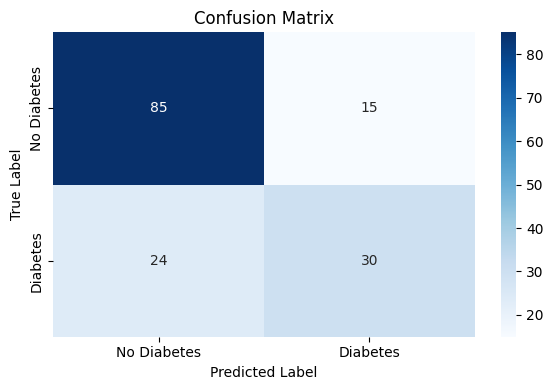

In [20]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 6. 피처 중요도 분석

**Gradient Boosting 피처 중요도**
- 각 트리에서 피처가 분할에 기여한 정도
- 손실 함수 감소량 기반
- 높은 값: 예측에 중요한 피처

In [15]:
# 피처 중요도 추출
importances = best_clf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# 중요도 정렬
importance_df = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

print("\n피처 중요도 순위:")
print(importance_df.to_string(index=False))


피처 중요도 순위:
Feature  Importance
   plas    0.561286
   mass    0.207592
    age    0.104731
   pedi    0.056015
   preg    0.035587
   insu    0.024126
   pres    0.007830
   skin    0.002832


**피처 중요도 시각화**

/tmp/ipython-input-2497543867.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


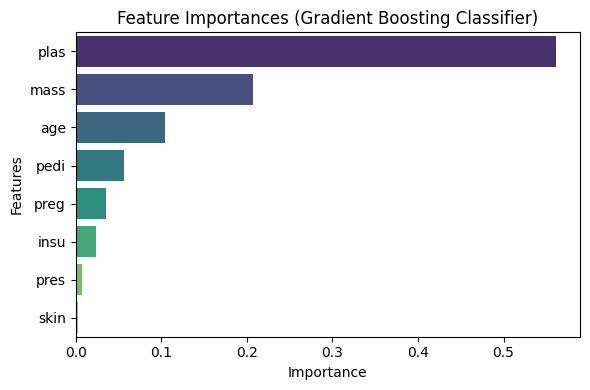

In [21]:
# 피처 중요도 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title("Feature Importances (Gradient Boosting Classifier)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## 7. 앙상블 모델 비교

**GB vs Random Forest vs AdaBoost**


앙상블 모델 비교:
Gradient Boosting: Accuracy = 0.7468
Random Forest: Accuracy = 0.7597
AdaBoost: Accuracy = 0.7922


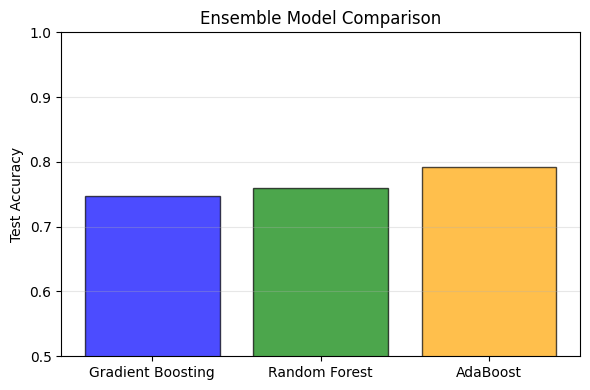

In [22]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)
accuracy_rf = rf_clf.score(X_test, y_test)

# AdaBoost
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=100,
    random_state=42
)
ada_clf.fit(X_train, y_train)
accuracy_ada = ada_clf.score(X_test, y_test)

# 비교
print("\n앙상블 모델 비교:")
print(f"Gradient Boosting: Accuracy = {test_accuracy:.4f}")
print(f"Random Forest: Accuracy = {accuracy_rf:.4f}")
print(f"AdaBoost: Accuracy = {accuracy_ada:.4f}")

# 시각화
models = ['Gradient Boosting', 'Random Forest', 'AdaBoost']
scores = [test_accuracy, accuracy_rf, accuracy_ada]

plt.figure(figsize=(6, 4))
plt.bar(models, scores, color=['blue', 'green', 'orange'], alpha=0.7, edgecolor='k')
plt.ylabel('Test Accuracy')
plt.title('Ensemble Model Comparison')
plt.ylim(0.5, 1.0)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 8. Learning Rate 영향 분석

**다양한 learning_rate의 영향**

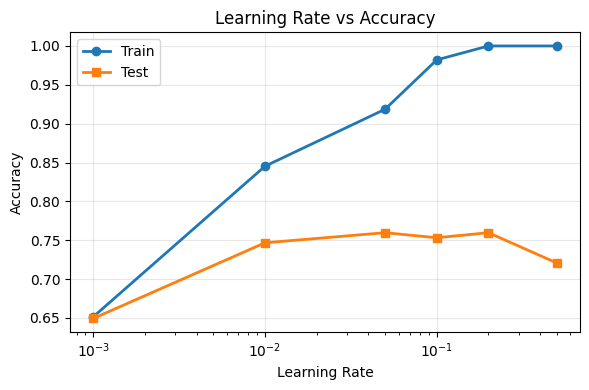

In [23]:
# learning_rate별 성능
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]
train_scores = []
test_scores = []

best_params = grid_clf.best_params_

for lr in learning_rates:
    gb = GradientBoostingClassifier(
        n_estimators=best_params['n_estimators'],
        learning_rate=lr,
        max_depth=best_params['max_depth'],
        subsample=best_params['subsample'],
        random_state=42
    )
    gb.fit(X_train, y_train)
    train_scores.append(gb.score(X_train, y_train))
    test_scores.append(gb.score(X_test, y_test))

# 시각화
plt.figure(figsize=(6, 4))
plt.plot(learning_rates, train_scores, marker='o', label='Train', linewidth=2)
plt.plot(learning_rates, test_scores, marker='s', label='Test', linewidth=2)
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Learning Rate vs Accuracy')
plt.xscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. 학습 곡선 (Deviance Plot)

**트리 개수에 따른 손실 함수 감소**

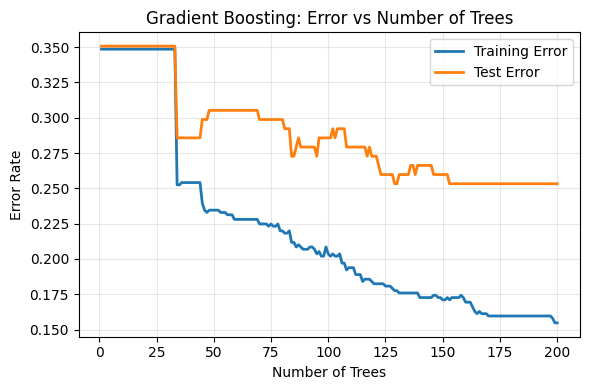

In [24]:
# 학습 곡선 (누적 손실)
train_score = np.zeros((best_params['n_estimators'],), dtype=np.float64)
test_score = np.zeros((best_params['n_estimators'],), dtype=np.float64)

for i, y_pred_train in enumerate(best_clf.staged_predict(X_train)):
    train_score[i] = 1 - accuracy_score(y_train, y_pred_train)

for i, y_pred_test in enumerate(best_clf.staged_predict(X_test)):
    test_score[i] = 1 - accuracy_score(y_test, y_pred_test)

# 시각화
plt.figure(figsize=(6, 4))
plt.plot(range(1, best_params['n_estimators'] + 1), train_score,
         label='Training Error', linewidth=2)
plt.plot(range(1, best_params['n_estimators'] + 1), test_score,
         label='Test Error', linewidth=2)
plt.xlabel('Number of Trees')
plt.ylabel('Error Rate')
plt.title('Gradient Boosting: Error vs Number of Trees')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()